# Train world model

This notebook uses the balanced Dreamer-style recipe:
- KL scale 1.0 with a free-nats floor (so `z` is not pure noise, but also isn't
  forced to match the prior before it has anything useful to encode)
- Aux encoder→pixel recon (keeps perception sharp even if the RSSM lags)
- L1 recon at moderate scale

**Read this before panicking at a gray recon panel:** the decoder is
randomly initialized, so at step 1 its output is near-constant (~gray after
converting back to uint8) no matter how good the recipe is. `image_every`
is synced to `log_every` so the recon grid refreshes every time the loss
curve does — within the first ~50-100 steps you should see real structure
appear. If it's still flat after a few hundred steps, *that's* the signal
something is wrong, not step 1 looking flat.

Watch two recon curves: `recon` (`[h,z]`) and `recon_embed` (encoder). The
embed path should get readable structure first; `[h,z]` follows.

The top-left chart plots each term's **actual contribution to the total
loss** (i.e. already multiplied by its own `*_scale`, matching what
`world_model_loss` sums into `total`). `kl` looks tiny in isolation
(`0.6 = 0.5*kl_dyn + 0.1*kl_rep` at the free-nats floor) purely because
`dyn_scale`/`rep_scale` are small -- once `recon_scale=5.0` is applied to the
raw ~0.1-0.2 pixel loss, recon and kl end up roughly the same size. If you
ever want the raw, un-scaled per-term values instead, they're still in
`history` (e.g. `history[-1]["recon"]`).

The `kl_dyn_raw` / `kl_rep_raw` panel shows the *total* KL of the latent
(summed across all `stoch` categorical variables — they're independent, so
joint KL is a sum, not an average). It's completely normal for this to sit
at or below the `free_nats` line for the entire run — the free-nats floor
exists exactly so the model pays no extra penalty for living at that budget.
**It does not need to cross the line, ever.** What actually matters:
it shouldn't collapse toward 0 (dead latent, posterior == prior) and
shouldn't blow up to huge values (posterior ignoring the prior completely,
bad for imagination). A curve that dips, then plateaus somewhere in the
0.3-1.5 nat range, is healthy.

A full 12000-step run is ~90-100 minutes on Apple Silicon MPS. Set
`STEPS_OVERRIDE = 500` for a quick smoke test before committing to a full run.

**Latent capacity bumped 16x16 -> 32x32** (DreamerV3's standard size,
arXiv:2301.04104) after a prior run's `recon` genuinely plateaued around step
8-9k (confirmed via the trend readout, not just noise) with visibly blurry
`[h,z]` reconstructions. This is a real architecture/checkpoint shape change
-- old checkpoints under `checkpoints/m3_world_model/` won't load; start
fresh with `RESUME = None`.

**Set expectations correctly:** the `[h,z]` panel will likely never look as
sharp as M1's `recon_final.png`. M1's autoencoder uses U-Net skip connections
straight from the raw input plus a near-copy residual head -- a legitimate
trick for a pure image-in/image-out task, but structurally impossible for the
`[h,z]` decoder, which must reconstruct purely from imagined state with zero
access to real pixels during rollouts (that's the whole point of a world
model). The only honest lever for its sharpness is real latent/model
capacity, which is what this change increases. `embed` (bypassing the RSSM
entirely) can look sharper than `[h,z]` -- that gap is expected, not a bug.

**Extending a run instead of restarting:** if training is still improving (check the `recon trend` line) when it hits `steps`, don't throw it away and start cold again -- that wastes the hour you already spent. Set `RESUME = "checkpoints/m3_world_model/ckpt_final.pt"` (or any `ckpt_step_*.pt`) and `STEPS_OVERRIDE = <extra steps>`, then Kernel -> Restart -> run all. The model/optimizer state loads and training continues from that checkpoint's step count. Note the loss chart for a resumed run only plots the *new* steps (history isn't reloaded from `train_metrics.json`), so the x-axis will start near wherever you resumed from, not 0.

**Added an edge-aware `grad` loss term (new `grad_scale` in the config).** A
32x32-latent run was still genuinely improving at step ~9k (the `recon trend`
readout showed it dropping, not plateaued), yet the background and HUD bar
stayed blurry/illegible. That rules out "ran out of capacity" as the cause --
the real culprit is the objective itself: plain per-pixel L1 rewards matching
a region's *average* color, and a 1-2px sprite outline or HUD icon/number
stroke is a tiny fraction of a region's pixels (checked a real frame: the
HUD bar's icon/number detail lives in ~4 of its ~15 rows, the rest is flat
black), so getting it exactly right barely moves that average. `grad_scale`
adds `gradient_l1_loss` -- an L1 loss on image finite-difference gradients --
which explicitly rewards matching *where* the image changes (edges, outlines,
digits), not just its color. Watch the new `grad` line on the loss chart
below; if it's dropping while `recon` also keeps dropping, edges are
sharpening for real.

**`grad_scale` correction (15.0 -> 1.5):** the first value was calibrated
against an *untrained* model, where `grad_raw` and `recon_raw` happen to be
similar magnitude. But `recon`/`recon_embed` converge fast while `grad_raw`
barely moves -- Crafter's dithered grass/dirt textures have per-pixel noise,
and matching that noise's *exact* gradient is much harder than matching
overall color even for an otherwise-good reconstruction. That ratio inverted
within ~400 steps: `grad` ballooned to ~70% of the total loss, dragging
training toward chasing near-unlearnable texture noise instead of actual
image quality -- visible as the `grad` line sitting flat near the top of the
scaled-contribution chart while `recon`/`recon_embed` dropped underneath it.
`1.5` keeps `grad`'s scaled contribution a *minority* of `recon` +
`recon_embed`'s combined contribution -- a sharpening nudge, not the primary
objective. If `grad`'s scaled line ever climbs back above the combined
recon lines, that's the signal to lower it again.

This is a loss-function-only change (model architecture is unchanged from
the 32x32-latent run), but since it changes what the model is optimized for,
start fresh rather than resuming a checkpoint trained under the old
objective: `RESUME = None`.

**`free_nats` bumped 1.0 -> 3.0, then reverted (RSSM-side fix, didn't pan
out):** `notebooks/06_decoder_probe.ipynb` showed a fresh decoder on this
checkpoint's frozen `[h,z]` only beat the original by +6-8% -- so the latent
itself wasn't encoding scattered mobs/trees/rocks. Raising `free_nats` was
meant to give the model more free budget, but resuming under it made `recon`
regress (-11.7% trend, i.e. got *worse*) and inflated the KL loss's on-chart
size without real signal: with most per-timestep KL sitting below the new
3.0 floor, `clamp_min` bumped them *up* to exactly 3.0 for the loss average
-- but `clamp_min`'s gradient is zero there, so that inflated the number
without adding any actual pressure to use more bits. Reverted to `1.0`.

**Real root cause found: the encoder had a hidden mixing bottleneck.**
`encoder.embed_dim` was `2048` while `channels=[64,128,256,512]` flattens to
`8192` -- since those don't match, `Encoder` (see its own docstring) inserts
`nn.Linear(8192, 2048)`, a dense layer that mixes *every spatial location*
together before the RSSM ever sees the embedding. M1's config already used
`embed_dim=8192` with these exact channels for exactly this reason (`8192 ==
512*4*4`, no mixing linear, spatial layout preserved) -- that's *why* M1 hit
near-pixel-identical recon. M3 lost that property when `embed_dim` was
raised for "more capacity" without preserving the flat_dim match, silently
throwing away the spatial precision needed to encode small scattered
objects. Fixed: `embed_dim: 8192` now, matching `channels[-1]*4*4` exactly
(both the encoder's and the embed_decoder's mixing linears are now
`Identity()` -- verified directly). No amount of `free_nats`/`grad_scale`/
RSSM-size tuning could have fixed this since the detail never reached the
RSSM in the first place.

**This is a shape change -- old checkpoints will NOT load.** Start fresh
with `RESUME = None`. That run reached step 9600 and the embed_dim fix alone
was NOT enough: both `[h,z]` recon AND `recon_embed` still had zero
trees/mobs/HUD digits and a blank inventory bar. That was the key clue --

**Real root cause #2: `recon_embed`'s decoder had no skip connections.**
`recon_embed` is a pure `encode(real frame) -> embed -> decode(embed)` round
trip with **no RSSM/KL involved at all** -- exactly the image reconstruction
problem M1 already solved to near-pixel-identical quality. The only
structural difference from M1's proven setup: M1's `PerceptionAutoencoder`
decodes with full U-Net skip connections (stem@64 + 3 intermediate
resolutions); M3's `embed_decoder` was a plain skip-free `Decoder` funneling
everything through one 4x4 bottleneck. M1's own no-skip ablation
(`results/m1/recon_no_obs_skip.png`) already showed exactly this failure
mode -- skip-free reconstruction loses small/sparse detail regardless of
how wide the embedding is (we'd already ruled out embedding capacity with
the 2048->8192 fix). Confirmed the fix is legitimate, not a shortcut: skips
are only valid for `recon_embed` because it always decodes an embedding
computed from a REAL frame, so that same frame's own intermediate encoder
activations exist to skip from. The primary `[h,z]` decoder is UNCHANGED
and stays skip-free -- imagination has no real frame to skip from, so this
fix cannot and does not apply there directly. What it should do indirectly:
a properly-supervised encoder (real gradient signal for preserving small
objects, not just average color) gives the RSSM's posterior a richer
embedding to compress into `z`.

**Implementation:** `WorldModel` now holds a `perception:
PerceptionAutoencoder` (encoder + U-Net skip decoder, M1's exact class)
instead of a separate `Encoder` + skip-free `embed_decoder`. New
`encoder.stem_channels: 64` config key (matches M1). This is a real
architecture/checkpoint shape change -- old checkpoints will NOT load;
start fresh with `RESUME = None`.

**Throughput measured, not just estimated:** a smoke test with the real
config dims on MPS showed ~1.16 steps/s -- essentially unchanged from before
this fix (~1.2 steps/s), because the RSSM's recurrence over 32 timesteps and
the `embed_dim=8192` linears already dominated compute; the added U-Net
skip convs are comparatively cheap. A full 12000-step run is still
~2.5-3 hours. Set `STEPS_OVERRIDE = 3000` first (~45 min) specifically to
check `recon_embed` for trees/mobs/HUD digits before committing to a full
run -- if skips are working, `recon_embed` should look dramatically better
than `[h,z]` early on, well before `[h,z]` catches up (if it ever fully
does -- see the capacity/imagination note above).

Before running: **stop any other kernel still training the old
config/checkpoint** -- it loaded the old settings into memory already and
won't pick up these file changes until restarted.

Kernel -> Restart -> run all. `RESUME = None`, `STEPS_OVERRIDE = 3000` for the first check.

In [1]:
from __future__ import annotations

import importlib
import json
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
from IPython.display import clear_output, display
from torch.utils.tensorboard import SummaryWriter

import models.decoder as decoder_mod
import models.world_model as wm_mod
import training.losses as losses_mod
from models.preprocess import nchw_float_to_nhwc_uint8, nhwc_uint8_to_nchw_float
from training.device import get_device
from training.replay_buffer import ReplayBuffer, collect_random_episodes

importlib.reload(losses_mod)
importlib.reload(decoder_mod)
importlib.reload(wm_mod)
world_model_loss = losses_mod.world_model_loss
WorldModel = wm_mod.WorldModel

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

%matplotlib inline

CONFIG = Path("configs/m3_world_model.yaml")
# WorldModel now uses PerceptionAutoencoder (U-Net skips) for recon_embed --
# a shape change (encoder.* / embed_decoder.* -> perception.*), old
# checkpoints will NOT load.
RESUME = None
STEPS_OVERRIDE: int | None = 3000  # sanity-check recon_embed before a full run
RECOLLECT = False  # True only if you still need the 80-episode dump

with CONFIG.open() as f:
    cfg = yaml.safe_load(f)

seed = int(cfg["seed"])
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
device = get_device()
print(f"device: {device}")
if device.type != "mps":
    print(
        "WARNING: not running on MPS -- training will be ~10-20x slower on CPU. "
        "Check torch.backends.mps.is_available() and that this isn't running "
        "inside a sandboxed shell/container without GPU access."
    )
print(
    f"recon_scale={cfg['train']['recon_scale']} "
    f"recon_embed_scale={cfg['train'].get('recon_embed_scale')} "
    f"grad_scale={cfg['train'].get('grad_scale', 0.0)} "
    f"kl_scale={cfg['train']['kl_scale']} free_nats={cfg['train']['free_nats']}"
)


device: mps
recon_scale=5.0 recon_embed_scale=5.0 grad_scale=1.5 kl_scale=1.0 free_nats=1.0


In [2]:
replay_path = Path(cfg["collect"]["out_path"])
if RECOLLECT or not replay_path.exists():
    print(f"collecting {cfg['collect']['num_episodes']} episodes…")
    buf = collect_random_episodes(
        env_id=str(cfg["env"]["id"]),
        num_episodes=int(cfg["collect"]["num_episodes"]),
        max_episode_steps=int(cfg["collect"]["max_episode_steps"]),
        action_dim=int(cfg["env"]["action_dim"]),
        seed=seed,
    )
    replay_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(buf.state_dict(), replay_path)
    print(f"wrote {replay_path}: episodes={len(buf)} steps={buf.num_steps}")
else:
    print(f"using existing {replay_path}")

buffer = ReplayBuffer(seed=seed)
buffer.load_state_dict(torch.load(replay_path, weights_only=False))
print(f"replay: episodes={len(buffer)} steps={buffer.num_steps}")


using existing data/m3_replay.pt
replay: episodes=80 steps=13669


In [3]:
enc, rssm, dec, heads, train_cfg = (
    cfg["encoder"],
    cfg["rssm"],
    cfg.get("decoder", {}),
    cfg.get("heads", {}),
    cfg["train"],
)
model = WorldModel.from_config_dims(
    embed_dim=int(enc["embed_dim"]),
    encoder_channels=tuple(int(c) for c in enc["channels"]),
    action_dim=int(cfg["env"]["action_dim"]),
    deter_dim=int(rssm["deter_dim"]),
    stoch=int(rssm["stoch"]),
    classes=int(rssm["classes"]),
    hidden=int(rssm["hidden"]),
    unimix=float(rssm.get("unimix", 0.01)),
    act=str(rssm.get("act", "silu")),
    initial=str(rssm.get("initial", "learned")),
    rec_depth=int(rssm.get("rec_depth", 1)),
    decoder_channels=tuple(int(c) for c in dec.get("channels", [512, 256, 128, 64])),
    head_hidden=int(heads.get("hidden", 512)),
    head_layers=int(heads.get("layers", 2)),
    stem_channels=int(enc.get("stem_channels", 64)),
).to(device)
optim = torch.optim.Adam(model.parameters(), lr=float(train_cfg["lr"]))
start_step = 0
if RESUME is not None:
    ckpt = torch.load(Path(RESUME), weights_only=False, map_location=device)
    model.load_state_dict(ckpt["model"], strict=True)
    if "optim" in ckpt:
        optim.load_state_dict(ckpt["optim"])
    start_step = int(ckpt.get("step", 0))
    print(f"resumed from {RESUME} at step {start_step}")
print(f"params: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")


params: 29.99M


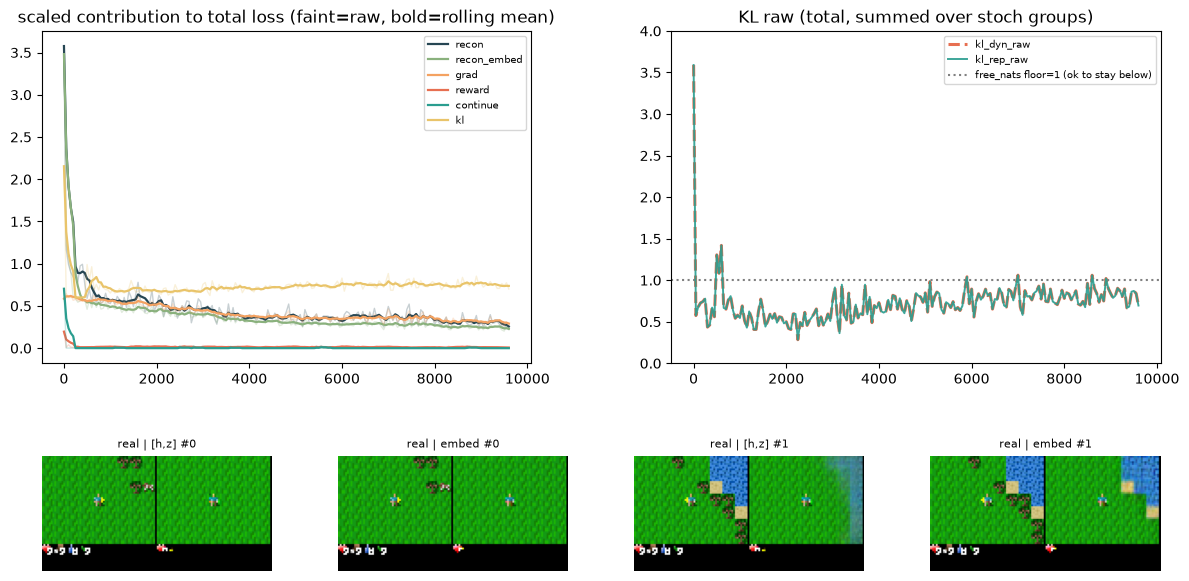

step  9600/12000  recon=0.0445 emb=0.0440 grad=0.1857  kl_raw=0.695/0.695 (dyn==rep, overlap is normal)
  scaled contributions to total: recon=0.223 recon_embed=0.220 grad=0.278 reward=0.007 continue=0.000 kl=0.700  | free_nats=1
  recon trend: last 500 steps avg=0.0581 vs prior 500 steps avg=0.0599 (+3.1%)


KeyboardInterrupt: 

In [4]:
log_dir = Path(train_cfg["log_dir"])
ckpt_dir = Path(train_cfg["checkpoint_dir"])
results_dir = Path(train_cfg["results_dir"])
for p in (log_dir, ckpt_dir, results_dir):
    p.mkdir(parents=True, exist_ok=True)
writer = SummaryWriter(log_dir=str(log_dir))

steps = int(STEPS_OVERRIDE) if STEPS_OVERRIDE is not None else int(train_cfg["steps"])
batch_size = int(train_cfg["batch_size"])
seq_len = int(train_cfg["seq_len"])
log_every = int(train_cfg["log_every"])
image_every = int(train_cfg["image_every"])
ckpt_every = int(train_cfg["checkpoint_every"])

import time

history: list[dict] = []
last_recon_vis = None
last_log_time = time.time()
last_log_step = start_step


def show_progress(history, recon_vis, steps_per_sec=None):
    clear_output(wait=True)
    xs = [h["step"] for h in history]
    fig = plt.figure(figsize=(12, 7))
    ax0 = fig.add_subplot(2, 2, 1)
    # Plot each term's ACTUAL contribution to `total` (i.e. multiplied by its
    # own *_scale). `kl` already bakes in dyn_scale/rep_scale internally, so
    # comparing it directly against unscaled recon/recon_embed made recon look
    # negligible even when it was contributing just as much to the real total.
    scales = {
        "recon": float(train_cfg["recon_scale"]),
        "recon_embed": float(train_cfg.get("recon_embed_scale", 1.0)),
        "grad": float(train_cfg.get("grad_scale", 0.0)),
        "reward": float(train_cfg["reward_scale"]),
        "continue": float(train_cfg["continue_scale"]),
        "kl": float(train_cfg["kl_scale"]),
    }
    def rolling_mean(values: list[float], window: int = 5) -> list[float]:
        out = []
        for i in range(len(values)):
            lo = max(0, i - window + 1)
            out.append(sum(values[lo : i + 1]) / (i - lo + 1))
        return out

    for key, color in [
        ("recon", "#264653"),
        ("recon_embed", "#8ab17d"),
        ("grad", "#f4a261"),
        ("reward", "#e76f51"),
        ("continue", "#2a9d8f"),
        ("kl", "#e9c46a"),
    ]:
        raw = [h[key] * scales[key] for h in history]
        # Each point is a single small (batch_size=4) minibatch's loss, so the
        # raw curve is noisy even while the underlying trend is improving. Plot
        # the noisy trace faint + a rolling mean on top so the trend is legible.
        ax0.plot(xs, raw, color=color, alpha=0.25, linewidth=1)
        ax0.plot(xs, rolling_mean(raw), label=key, color=color, linewidth=1.6)
    ax0.set_title("scaled contribution to total loss (faint=raw, bold=rolling mean)")
    ax0.legend(fontsize=7)

    ax1 = fig.add_subplot(2, 2, 2)
    dyn_ys = [h["kl_dyn_raw"] for h in history]
    rep_ys = [h["kl_rep_raw"] for h in history]
    # These two are often numerically identical (same categorical KL, just
    # opposite .detach() sides for the gradient). Plotting solid-on-solid then
    # hides the first series completely -- which is why "kl_dyn_raw" looked
    # missing. Draw dyn as a thicker dashed line underneath, rep solid on top,
    # so both stay legible even when they overlap.
    ax1.plot(xs, dyn_ys, label="kl_dyn_raw", color="#e76f51", ls="--", linewidth=2.2, zorder=2)
    ax1.plot(xs, rep_ys, label="kl_rep_raw", color="#2a9d8f", ls="-", linewidth=1.4, zorder=3, alpha=0.9)
    # This is a MINIMUM the KL gets no penalty for staying at/below, not a target
    # it needs to cross -- see DreamerV3 paper eq. 5: max(1, KL) exists precisely
    # to switch the KL loss off once already small, not to pull it upward.
    free_nats = float(train_cfg["free_nats"])
    ax1.axhline(
        free_nats, color="gray", ls=":", linewidth=1.5,
        label=f"free_nats floor={free_nats:g} (ok to stay below)",
    )
    # Keep the floor readable: don't let a single resume spike blow the y-axis
    # up so the free_nats line sits on the ceiling and the real signal looks flat.
    data_max = max(dyn_ys + rep_ys + [0.0])
    ax1.set_ylim(0.0, max(free_nats * 1.25, min(data_max * 1.15, free_nats * 4.0), 1.0))
    ax1.set_title("KL raw (total, summed over stoch groups)")
    ax1.legend(fontsize=7)

    if recon_vis is not None:
        real, pred_hz, pred_emb = recon_vis
        for i in range(min(2, real.shape[0])):
            ax = fig.add_subplot(2, 4, 5 + i * 2)
            ax.imshow(np.concatenate([real[i].numpy(), pred_hz[i].numpy()], axis=1))
            ax.set_title(f"real | [h,z] #{i}", fontsize=8)
            ax.axis("off")
            ax = fig.add_subplot(2, 4, 6 + i * 2)
            ax.imshow(np.concatenate([real[i].numpy(), pred_emb[i].numpy()], axis=1))
            ax.set_title(f"real | embed #{i}", fontsize=8)
            ax.axis("off")
    fig.tight_layout()
    display(fig)
    plt.close(fig)
    h = history[-1]
    sps = f" ({steps_per_sec:.2f} steps/s)" if steps_per_sec else ""
    contrib_str = " ".join(f"{k}={h[k] * scales[k]:.3f}" for k in scales)
    same = abs(h["kl_dyn_raw"] - h["kl_rep_raw"]) < 1e-4
    print(
        f"step {h['step']:5d}/{start_step + steps}  "
        f"recon={h['recon']:.4f} emb={h['recon_embed']:.4f} grad={h['grad']:.4f}  "
        f"kl_raw={h['kl_dyn_raw']:.3f}/{h['kl_rep_raw']:.3f}"
        f"{' (dyn==rep, overlap is normal)' if same else ''}{sps}\n"
        f"  scaled contributions to total: {contrib_str}  | free_nats={free_nats:g}"
    )
    # De-noise the "is it actually improving?" question: compare the mean of
    # the last chunk of logged points against the chunk before it, instead of
    # reading two single noisy points off the chart.
    n = len(history)
    chunk = max(1, min(10, n // 2))
    if n >= 2 * chunk:
        recent = sum(x["recon"] for x in history[-chunk:]) / chunk
        prior = sum(x["recon"] for x in history[-2 * chunk : -chunk]) / chunk
        pct = 100.0 * (1.0 - recent / max(prior, 1e-8))
        window_steps = chunk * log_every
        print(
            f"  recon trend: last {window_steps} steps avg={recent:.4f} vs "
            f"prior {window_steps} steps avg={prior:.4f} ({pct:+.1f}%)"
        )


model.train()
print(f"training {steps} steps on {device}…")
for step in range(start_step + 1, start_step + steps + 1):
    batch = buffer.sample(batch_size, seq_len)
    obs = batch["obs"].to(device)
    out = model(obs, batch["actions"].to(device))
    b, t = obs.shape[:2]
    obs_f = nhwc_uint8_to_nchw_float(obs.reshape(b * t, *obs.shape[2:])).view(b, t, 3, 64, 64)
    loss = world_model_loss(
        obs=obs_f,
        recon=out.recon,
        recon_embed=out.recon_embed,
        reward=batch["rewards"].to(device),
        reward_pred=out.reward_pred,
        cont=batch["cont"].to(device),
        cont_logit=out.cont_logit,
        post_logits=out.rssm.posterior_logits,
        prior_logits=out.rssm.prior_logits,
        unimix=model.rssm.unimix,
        dyn_scale=float(train_cfg["dyn_scale"]),
        rep_scale=float(train_cfg["rep_scale"]),
        free_nats=float(train_cfg["free_nats"]),
        recon_scale=float(train_cfg["recon_scale"]),
        recon_embed_scale=float(train_cfg.get("recon_embed_scale", 1.0)),
        reward_scale=float(train_cfg["reward_scale"]),
        continue_scale=float(train_cfg["continue_scale"]),
        kl_scale=float(train_cfg["kl_scale"]),
        grad_scale=float(train_cfg.get("grad_scale", 0.0)),
        recon_loss_type=str(train_cfg.get("recon_loss", "l1")),
    )
    optim.zero_grad(set_to_none=True)
    loss.total.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 100.0)
    optim.step()

    metrics = {
        "step": step,
        "total": float(loss.total.detach()),
        "recon": float(loss.recon.detach()),
        "recon_embed": float(loss.recon_embed.detach()),
        "grad": float(loss.grad.detach()),
        "reward": float(loss.reward.detach()),
        "continue": float(loss.continue_loss.detach()),
        "kl": float(loss.kl.detach()),
        "kl_dyn": float(loss.kl_dyn.detach()),
        "kl_rep": float(loss.kl_rep.detach()),
        "kl_dyn_raw": float(loss.kl_dyn_raw.detach()),
        "kl_rep_raw": float(loss.kl_rep_raw.detach()),
    }

    if step % log_every == 0 or step == start_step + 1:
        for k, v in metrics.items():
            if k != "step":
                writer.add_scalar(f"m3/{k}", v, step)
        history.append(metrics)
        now = time.time()
        steps_per_sec = (step - last_log_step) / max(now - last_log_time, 1e-6)
        last_log_time, last_log_step = now, step
        show_progress(history, last_recon_vis, steps_per_sec)

    if step % image_every == 0 or step == start_step + 1:
        model.eval()
        with torch.no_grad():
            vis = buffer.sample(min(4, batch_size), seq_len)
            v_out = model(vis["obs"].to(device), vis["actions"].to(device))
            real = vis["obs"][:, 0].cpu()
            pred_hz = nchw_float_to_nhwc_uint8(v_out.recon[:, 0].detach().cpu())
            pred_emb = nchw_float_to_nhwc_uint8(v_out.recon_embed[:, 0].detach().cpu())
            last_recon_vis = (real, pred_hz, pred_emb)
            from PIL import Image

            strips = [
                np.concatenate([real[i].numpy(), pred_hz[i].numpy(), pred_emb[i].numpy()], axis=1)
                for i in range(real.shape[0])
            ]
            Image.fromarray(np.concatenate(strips, axis=0), mode="RGB").save(
                results_dir / f"recon_step_{step:05d}.png"
            )
        model.train()
        if history:
            show_progress(history, last_recon_vis)

    if step % ckpt_every == 0:
        path = ckpt_dir / f"ckpt_step_{step:05d}.pt"
        torch.save({"step": step, "model": model.state_dict(), "optim": optim.state_dict()}, path)
        print(f"wrote {path}")

final = ckpt_dir / "ckpt_final.pt"
torch.save({"step": start_step + steps, "model": model.state_dict(), "optim": optim.state_dict()}, final)
(results_dir / "train_metrics.json").write_text(json.dumps(history, indent=2))
writer.flush(); writer.close()
show_progress(history, last_recon_vis)

# Definitive end-of-run grid (larger batch, holdout-ish sample) for the README-style
# before/after comparison, independent of whatever image_every last landed on.
model.eval()
with torch.no_grad():
    vis = buffer.sample(8, seq_len)
    v_out = model(vis["obs"].to(device), vis["actions"].to(device))
    real = vis["obs"][:, -1].cpu()
    pred_hz = nchw_float_to_nhwc_uint8(v_out.recon[:, -1].detach().cpu())
    pred_emb = nchw_float_to_nhwc_uint8(v_out.recon_embed[:, -1].detach().cpu())
    from PIL import Image

    strips = [
        np.concatenate([real[i].numpy(), pred_hz[i].numpy(), pred_emb[i].numpy()], axis=1)
        for i in range(real.shape[0])
    ]
    Image.fromarray(np.concatenate(strips, axis=0), mode="RGB").save(results_dir / "recon_final.png")
model.train()
print("done", final)


## Exit criteria — did this run actually work?

A healthy M3 run should show all of the following. This cell checks them
automatically instead of relying on eyeballing the curves.

**Important caveat, learned the hard way:** the pixel-std check below only
measures *aggregate* variance -- it cannot tell whether that variance is in
the right place. A model that nails big-block background color (grass green
vs. cave gray) while completely dropping every small object -- HUD digits,
mobs, trees, precise player pose -- can still pass every check here, because
those details are a tiny fraction of the frame's 4096 pixels and barely move
an aggregate loss/variance number either way. **Always look at
`recon_final.png` yourself; don't trust this cell alone for visual quality.**

What this cell (and M3's actual documented exit criteria in `milestones.md`)
*does* verify is the thing M3 is actually about: loss terms decreasing, KL
neither dead nor exploded, and reward predictions correlating with real
reward -- i.e. whether the compact `[h,z]` latent is control-useful, which is
the point of a world model. Photorealistic-looking reconstruction of every
mob and tree is a much harder, open-ended target that isn't part of that bar
(and isn't how any published Dreamer result on Crafter looks either) --
treat the recon panel as a *diagnostic* (is the latent dead? did the decoder
collapse?), not a pass/fail quality gate on its own.

In [ ]:
assert len(history) >= 2, "need at least two logged points to judge a trend"

first, last = history[0], history[-1]
checks: list[tuple[str, bool, str]] = []


def pct_drop(key: str) -> float:
    return 1.0 - (last[key] / max(first[key], 1e-8))


for key, min_drop in [("recon", 0.5), ("recon_embed", 0.5)]:
    drop = pct_drop(key)
    checks.append(
        (
            f"{key} loss dropped >= {min_drop:.0%} (first={first[key]:.4f} -> last={last[key]:.4f}, "
            f"actual={drop:.0%})",
            drop >= min_drop,
            "recon isn't improving — check lr, recon_scale, or a decoder/data bug",
        )
    )

# kl_dyn_raw is the TOTAL KL of the latent (summed over stoch groups). It is
# expected to sit at/below free_nats for most (or all) of training -- that's
# what the free-nats floor is for, not a target to exceed. The actual failure
# modes are collapse toward ~0 (dead latent) or blowing up to many nats
# (posterior ignoring the prior, bad for imagination rollouts).
kl_dyn_last = last["kl_dyn_raw"]
checks.append(
    (
        f"kl_dyn_raw isn't dead (last={kl_dyn_last:.3f} > 0.02)",
        kl_dyn_last > 0.02,
        "posterior has collapsed onto the prior -- latent carries ~no information",
    )
)
checks.append(
    (
        f"kl_dyn_raw hasn't exploded (last={kl_dyn_last:.3f} < 30.0)",
        kl_dyn_last < 30.0,
        "posterior is ignoring the prior entirely -- imagination rollouts will drift badly",
    )
)

# Pixel-collapse check: decoder output std should be in the same ballpark as
# real-image std, not near zero (solid color).
model.eval()
with torch.no_grad():
    vis = buffer.sample(8, seq_len)
    v_out = model(vis["obs"].to(device), vis["actions"].to(device))
    obs_f = nhwc_uint8_to_nchw_float(vis["obs"].to(device))
    obs_std = float(obs_f.std())
    recon_std = float(v_out.recon.std())
    embed_std = float(v_out.recon_embed.std())
model.train()

for name, std in [("recon", recon_std), ("recon_embed", embed_std)]:
    ratio = std / max(obs_std, 1e-8)
    checks.append(
        (
            f"{name} pixel std is close to real ({name}_std={std:.4f} vs obs_std={obs_std:.4f}, "
            f"ratio={ratio:.2f})",
            ratio > 0.4,
            f"{name} has collapsed toward a constant (solid-color) output -- NOTE: this "
            "only checks aggregate variance, not whether it's in the right place. Nailing "
            "background color while dropping every small object (HUD digits, mobs, trees, "
            "precise player pose) still passes this check -- eyeball recon_final.png too.",
        )
    )

# M3's actual documented exit criterion (milestones.md): reward prediction
# CORRELATES with real reward on held-out sequences -- this is what tests
# whether the latent is control-useful, independent of pixel fidelity.
true_chunks, pred_chunks = [], []
with torch.no_grad():
    for _ in range(20):
        rb = buffer.sample(batch_size, seq_len)
        r_out = model(rb["obs"].to(device), rb["actions"].to(device))
        true_chunks.append(rb["rewards"].numpy().reshape(-1))
        pred_chunks.append(r_out.reward_pred.squeeze(-1).cpu().numpy().reshape(-1))
reward_true = np.concatenate(true_chunks)
reward_pred = np.concatenate(pred_chunks)
if reward_true.std() > 1e-8 and reward_pred.std() > 1e-8:
    reward_corr = float(np.corrcoef(reward_true, reward_pred)[0, 1])
    checks.append(
        (
            f"reward prediction correlates with real reward (r={reward_corr:.2f})",
            reward_corr > 0.3,
            "reward head isn't tracking real reward -- latent may not be carrying "
            "reward-relevant information",
        )
    )
else:
    print("[SKIP] reward correlation: too few nonzero-reward examples in this sample")

print(f"steps trained: {last['step']}\n")
all_pass = True
for description, ok, hint in checks:
    status = "PASS" if ok else "FAIL"
    print(f"[{status}] {description}")
    if not ok:
        print(f"       -> {hint}")
        all_pass = False

print()
print("RESULT:", "PASS — M3 world model looks healthy" if all_pass else "FAIL — see hints above")